# Steel Industry Energy Consumption Dataset

## Deep Exploratory Data Analysis & Feature Engineering

### Week 2 AI & ML Internship Task

This notebook performs exploratory data analysis (EDA), feature engineering, outlier detection, and visualization on the Steel Industry Energy Consumption dataset.

## Objective

The objective of this notebook is to understand the dataset, identify data quality issues, engineer meaningful features, analyze relationships among variables, and generate insights before building machine learning models.

## Import Libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [3]:
df = pd.read_csv("Steel_industry_data.csv")

## Dataset Inspection

Before performing analysis, the dataset is inspected to understand its size, columns, and overall structure.

In [4]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

df.head()

Shape of Dataset: (35040, 11)

Columns:
Index(['date', 'Usage_kWh', 'Lagging_Current_Reactive.Power_kVarh',
       'Leading_Current_Reactive_Power_kVarh', 'CO2(tCO2)',
       'Lagging_Current_Power_Factor', 'Leading_Current_Power_Factor', 'NSM',
       'WeekStatus', 'Day_of_week', 'Load_Type'],
      dtype='object')


,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type
0,01/01/2018 00:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load
1,01/01/2018 00:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load
2,01/01/2018 00:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load
3,01/01/2018 01:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load
4,01/01/2018 01:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load


## Dataset Information

This section provides information about the dataset, including the number of entries, data types, and non-null values for each column.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
dtypes: float64(6), 

## Statistical Summary

The statistical summary provides descriptive statistics for all numerical features, including mean, standard deviation, minimum, maximum, and quartile values.

In [6]:
df.describe()

,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM
count,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000,35040.000000
mean,27.386892,13.035384,3.870949,0.011524,80.578056,84.367870,42750.000000
std,33.444380,16.306000,7.424463,0.016151,18.921322,30.456535,24940.534317
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.200000,2.300000,0.000000,0.000000,63.320000,99.700000,21375.000000
50%,4.570000,5.000000,0.000000,0.000000,87.960000,100.000000,42750.000000
75%,51.237500,22.640000,2.090000,0.020000,99.022500,100.000000,64125.000000
max,157.180000,96.910000,27.760000,0.070000,100.000000,100.000000,85500.000000


## Missing Values

This section checks whether the dataset contains any missing values that may affect the analysis.

In [7]:
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
dtype: int64


## Duplicate Records

This section identifies duplicate rows in the dataset.

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## Date Conversion

The `date` column is converted into datetime format to enable extraction of useful time-based features such as hour, day of the week, month, and weekend information.

In [10]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

print(df['date'].dtype)

datetime64[ns]


In [11]:
# Hour
df['Hour'] = df['date'].dt.hour

# Day Name
df['Day'] = df['date'].dt.day_name()

# Month
df['Month'] = df['date'].dt.month

# Weekday / Weekend
df['Day_Type'] = df['date'].dt.dayofweek.apply(
    lambda x: 'Weekend' if x >= 5 else 'Weekday'
)

df[['date','Hour','Day','Month','Day_Type']].head()

,date,Hour,Day,Month,Day_Type
0,2018-01-01 00:15:00,0,Monday,1,Weekday
1,2018-01-01 00:30:00,0,Monday,1,Weekday
2,2018-01-01 00:45:00,0,Monday,1,Weekday
3,2018-01-01 01:00:00,1,Monday,1,Weekday
4,2018-01-01 01:15:00,1,Monday,1,Weekday


## Feature Engineering: Power Factor Ratio

A new feature called **Power Factor Ratio** is created by dividing the Leading Current Power Factor by the Lagging Current Power Factor. This feature may help identify the relationship between the two power factors.

In [12]:
df['Power_Factor_Ratio'] = (
    df['Leading_Current_Power_Factor'] /
    df['Lagging_Current_Power_Factor']
)

df[['Leading_Current_Power_Factor',
    'Lagging_Current_Power_Factor',
    'Power_Factor_Ratio']].head()

,Leading_Current_Power_Factor,Lagging_Current_Power_Factor,Power_Factor_Ratio
0,100.0,73.21,1.365934
1,100.0,66.77,1.497679
2,100.0,70.28,1.422880
3,100.0,68.09,1.468644
4,100.0,64.72,1.545117


## Feature Engineering: High Load

A binary feature named **High_Load** is created using the 75th percentile of energy consumption. Records above this threshold are labeled as 1, while the remaining records are labeled as 0.

In [13]:
# Calculate the 75th percentile
threshold = df['Usage_kWh'].quantile(0.75)

print("75th Percentile:", threshold)

# Create High_Load feature
df['High_Load'] = np.where(df['Usage_kWh'] > threshold, 1, 0)

# Check the distribution
df['High_Load'].value_counts()

75th Percentile: 51.2375


High_Load
0    26280
1     8760
Name: count, dtype: int64

## Updated Dataset

The dataset now includes the newly engineered features.

In [14]:
df.head()

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day,Month,Day_Type,Power_Factor_Ratio,High_Load
0,2018-01-01 00:15:00,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.365934,0
1,2018-01-01 00:30:00,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.497679,0
2,2018-01-01 00:45:00,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,1,Weekday,1.422880,0
3,2018-01-01 01:00:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.468644,0
4,2018-01-01 01:15:00,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,1,Weekday,1.545117,0


## Outlier Detection using IQR

The Interquartile Range (IQR) method is used to detect outliers in the `Usage_kWh` column. Values below the lower bound or above the upper bound are considered outliers.

In [15]:
# Calculate Q1 and Q3
Q1 = df['Usage_kWh'].quantile(0.25)
Q3 = df['Usage_kWh'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Calculate lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

# Detect outliers
outliers = df[(df['Usage_kWh'] < lower_bound) | (df['Usage_kWh'] > upper_bound)]

print("Number of Outliers:", len(outliers))

Q1: 3.2
Q3: 51.2375
IQR: 48.037499999999994
Lower Bound: -68.85624999999999
Upper Bound: 123.29374999999999
Number of Outliers: 328


## Boxplot of Usage_kWh

A boxplot is used to visualize the distribution of energy consumption and identify potential outliers.

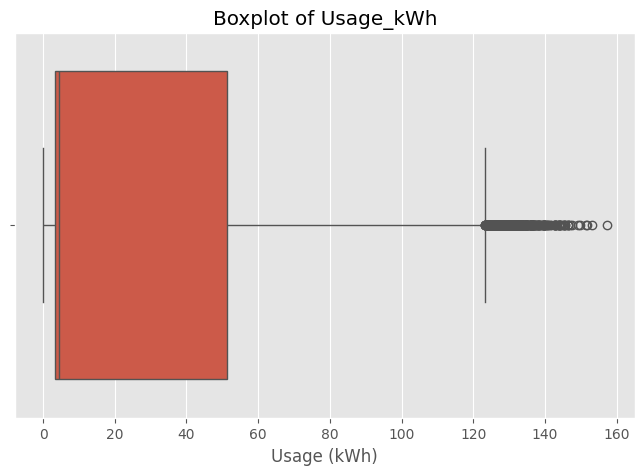

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['Usage_kWh'])

plt.title("Boxplot of Usage_kWh")
plt.xlabel("Usage (kWh)")

plt.show()

### Observation

The boxplot highlights the presence of outliers in the energy consumption values. These observations represent unusually high energy usage and may influence the performance of machine learning models if not handled appropriately.

## Correlation Analysis

A correlation heatmap is created to examine the relationships between numerical variables and identify the features that are most strongly associated with energy consumption.

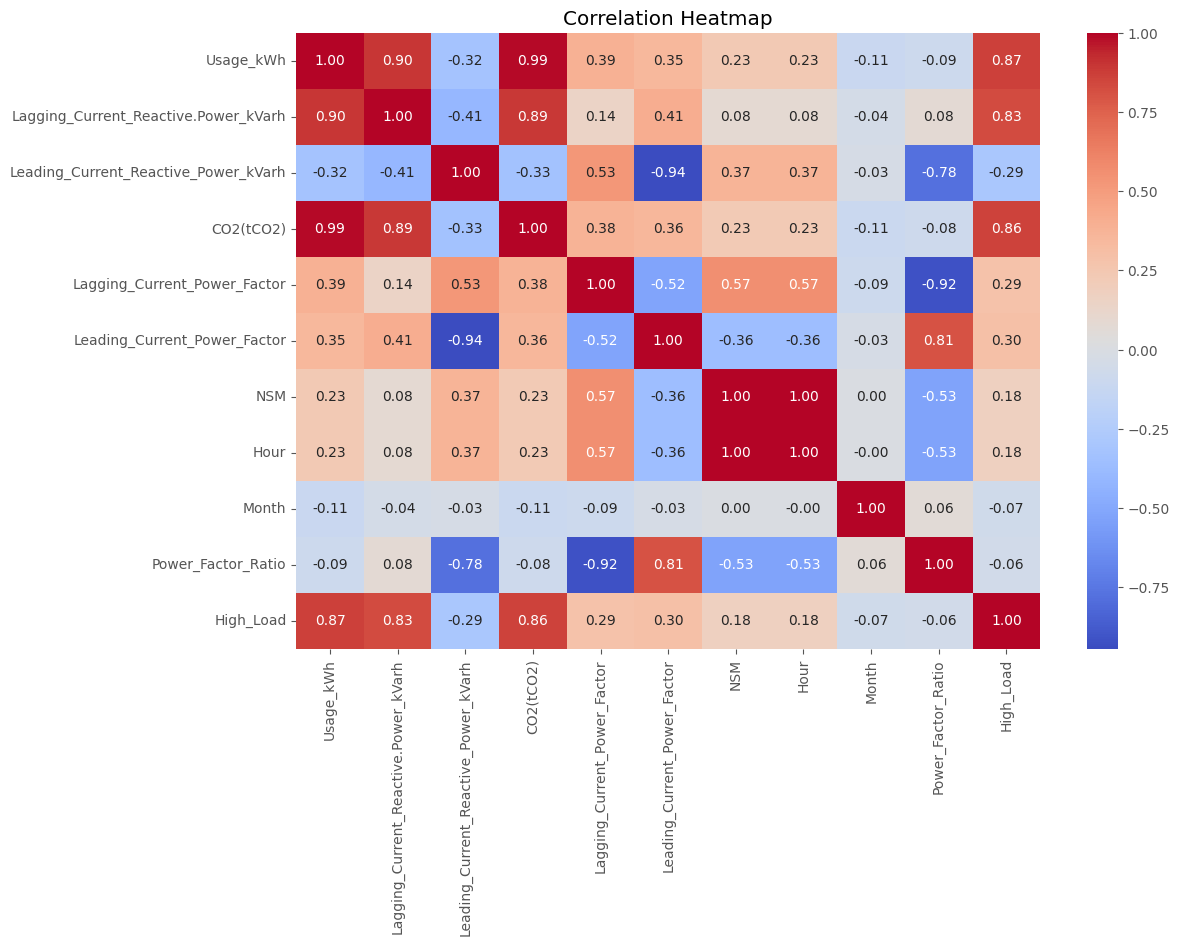

In [17]:
# Select numerical columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation matrix
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

## Top Correlated Features

The following code identifies the three numerical features that have the strongest correlation with `Usage_kWh`.

In [20]:
correlation = corr_matrix['Usage_kWh'].sort_values(ascending=False)

# Remove target itself and engineered feature
top3 = correlation.drop(['Usage_kWh', 'High_Load']).head(3)

print("Top 3 Features Correlated with Usage_kWh:")
print(top3)

Top 3 Features Correlated with Usage_kWh:
CO2(tCO2)                               0.98818
Lagging_Current_Reactive.Power_kVarh    0.89615
Lagging_Current_Power_Factor            0.38596
Name: Usage_kWh, dtype: float64


## Average Energy Consumption by Load Type

This visualization compares the average energy consumption across different load types.

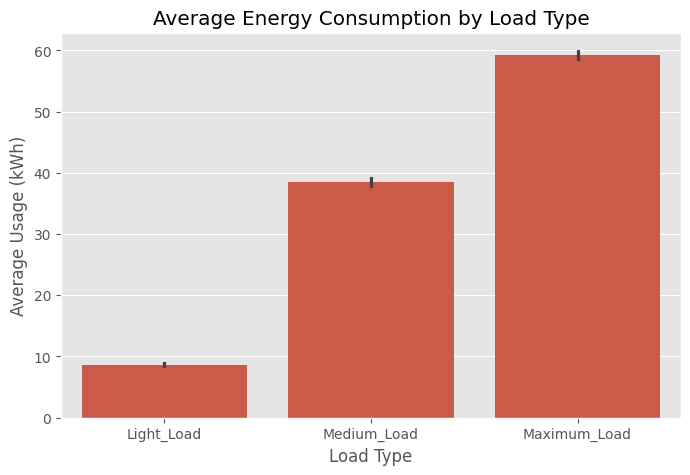

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Load_Type',
    y='Usage_kWh',
    estimator='mean'
)

plt.title("Average Energy Consumption by Load Type")
plt.xlabel("Load Type")
plt.ylabel("Average Usage (kWh)")

plt.show()

## Average Energy Usage by Hour

This line chart shows how average energy consumption changes throughout the day.

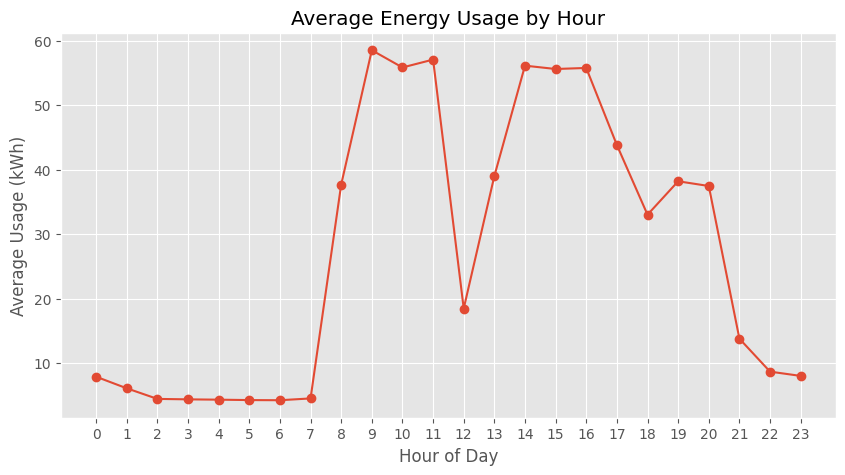

In [22]:
hourly_usage = df.groupby('Hour')['Usage_kWh'].mean()

plt.figure(figsize=(10,5))

plt.plot(hourly_usage.index,
         hourly_usage.values,
         marker='o')

plt.title("Average Energy Usage by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Usage (kWh)")

plt.xticks(range(24))

plt.grid(True)

plt.show()

## Save Engineered Dataset

The dataset with all newly engineered features is saved for use in the baseline regression modeling notebook.

In [24]:
df.to_csv("steel_energy_engineered.csv", index=False)

print("Engineered dataset saved successfully.")

Engineered dataset saved successfully.


## EDA Summary

The exploratory data analysis was conducted on the Steel Industry Energy Consumption dataset containing 35,040 records and 11 original features. The dataset was found to be clean and well-structured, with no missing values and no duplicate records, making it suitable for further analysis without extensive preprocessing.

Several new features were engineered to improve the dataset for machine learning. The `date` column was converted into datetime format, and new time-based features including Hour, Day, Month, and Day Type (Weekday/Weekend) were extracted. Additionally, a Power Factor Ratio feature was created using the leading and lagging current power factors, while a High Load indicator was generated based on the 75th percentile of energy consumption.

Outlier detection using the IQR method identified 328 outliers in the `Usage_kWh` column. These values represent unusually high energy consumption and may influence model performance. A boxplot was used to visualize these outliers.

Correlation analysis showed that `CO2(tCO2)` and `Lagging_Current_Reactive.Power_kVarh` were among the strongest predictors of energy consumption. This indicates that higher energy usage is strongly associated with increased carbon emissions and reactive power consumption. Energy usage also varied noticeably across different load types and hours of the day, suggesting that operational schedules have a significant impact on electricity demand.

A possible hypothesis is that energy spikes occur during maximum production periods when industrial machinery operates at higher capacity, resulting in increased electricity consumption, reactive power, and carbon emissions.